# NLP Visualising Embeddings

In [ ]:
# Implementing Dimensionality Reduction
# Reducing no. of features while preserving important imformation
# 100D- 2D
# We cannot analyse 100D
# This let us visually see :
# Similar Words cluster together
# Opposite words separate
# Semantic relationships

In [ ]:
'''
Types of dimensionality reduction: 
1. Feature Selection - remove some useless columns
2. Feature Extraction - create new features from existing columns

1. PCA- Linear Reduction
- PCA finds direction where data varies most
- these directions are principal components
Suppose Students:
- height and weight are co-related
- Instead of 2 features - PCA create 1 new feature representing both
Steps : 
- Standardize the data
- Compute co-variance matrix
- Find eigenVectors
- Select top components
- Project Data
Limitations :
1. Linear only
2. Cannot capture complex shapes

2. t-SNE - Non-Linear
- t-Distributed Stochastic Neighbour Embedding
- It actually preserves local structure i.e neighbours
- Points close in high dim - > close in low dim
Steps:
- It converts distance to probabilities
- Then tries to match them in low dimension
- Then uses KL Divergence
        
3. UMAP
- Uniform Manifold Approximation and Projection
- Modern alternative of t-SNE

'''

In [2]:
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
model=api.load("glove-wiki-gigaword-100")
print("Model loaded Successfully")

Model loaded Successfully


In [6]:
words=[
    "king","queen","man","woman","dog","cat","animal","car","truck","vehicle","happy","sad","joy","anger"
]
vectors=[model[word] for word in words]

In [8]:
pca=PCA(n_components=2)
reduced=pca.fit_transform(vectors)

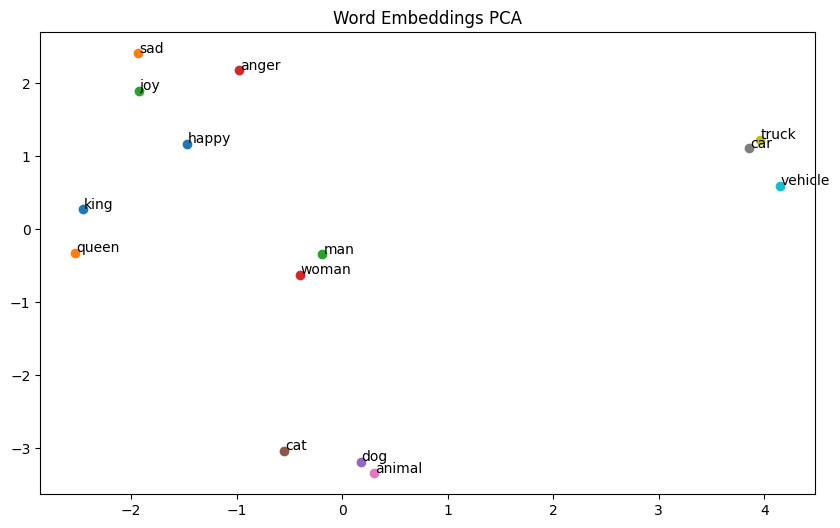

In [11]:
plt.figure(figsize=(10,6))
for i, word in enumerate(words):
    x=reduced[i][0]
    y=reduced[i][1]
    plt.scatter(x,y)
    plt.text(x+0.01,y+0.01,word)
plt.title("Word Embeddings PCA")
plt.show()

In [13]:
# Using t-SNE
from sklearn.manifold import TSNE
import numpy as np

In [21]:
vectors=np.array([model[word] for word in words])

In [22]:
# perplexity-  how many neighbours each point considers
tsne=TSNE(n_components=2,perplexity=3)
reduced=tsne.fit_transform(vectors)

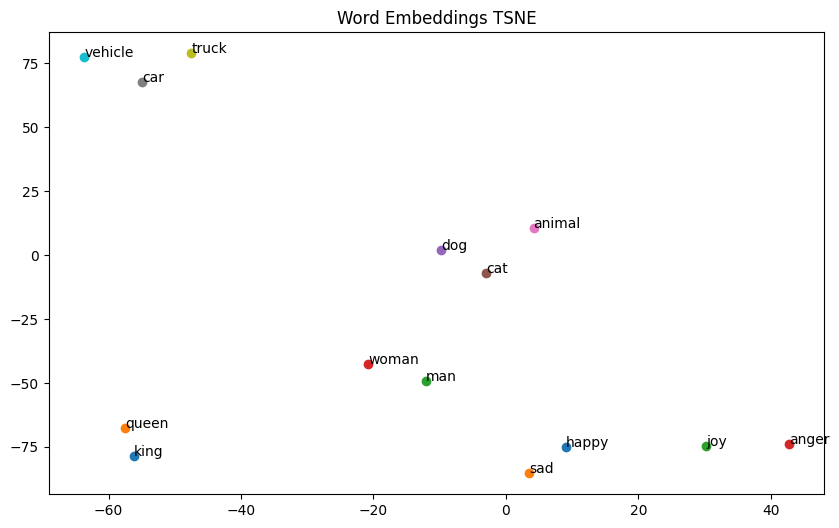

In [23]:
plt.figure(figsize=(10,6))
for i, word in enumerate(words):
    x=reduced[i][0]
    y=reduced[i][1]
    plt.scatter(x,y)
    plt.text(x+0.01,y+0.01,word)
plt.title("Word Embeddings TSNE")
plt.show()